In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from typing import Dict, Tuple

import os
from tqdm import tqdm

# Load metainfo and params

In [2]:
post_info_df = pd.read_csv("configs/post_info.csv", index_col=False)

In [3]:
POSTS_DIR = 'data/processed_data'
PLOTS_DIR = 'plots/'
os.makedirs(PLOTS_DIR, exist_ok=True)

files_name = os.listdir(POSTS_DIR)

In [4]:
# post_1_ind = 20
# post_2_ind = 12
# print(files_name[post_1_ind], files_name[post_2_ind])

# post_1_data = pd.read_csv(os.path.join(POSTS_DIR,files_name[post_1_ind]))
# post_2_data = pd.read_csv(os.path.join(POSTS_DIR,files_name[post_2_ind]))

In [5]:
# import json
# with open('configs/post_dict.json', 'r') as f:
#     posts_dir = json.load(f)

In [6]:
# post_ind = [posts_dir[item] for item in files_name]

In [7]:
# post_1_data['datetime'] = pd.to_datetime(post_1_data['datetime'])
# post_1_data['sea_level'] = pd.to_numeric(post_1_data['sea_level'], errors='coerce')

# post_2_data['datetime'] = pd.to_datetime(post_2_data['datetime'])
# post_2_data['sea_level'] = pd.to_numeric(post_2_data['sea_level'], errors='coerce')

In [8]:
# 75 на 65 или 80 на 60
width = 80
height = 60

color_1 = "#fa0000" # линия регрессии
color_2 = "#303946" # "#393939" серый первый вариант
color_3 = "#1F77B4" # tab10[0]
color_4 = "#FF7F0E" # tab10[1]
color_5 = "#00BFFF" # scatter plot в fig2

# fig 2
figure_1_color_1 = "#1F77B4"
figure_1_color_2 =  "#FF9334" #"#FF9334"

# fig 3
if ((width==75) and (height==65)):
    figure_2_color_1 = "#1F77B4"
    figure_2_color_2 = "#fa0000"
elif ((width==80) and (height==60)):
    figure_2_color_1 = "#1F77B4" #"#00BFFF"
    figure_2_color_2 = "#fa0000" #"#1F77B4"
else:
    raise ValueError

# fig 4
figure_3_color_1 = "#1F77B4" # "#666666"

plt.rcParams.update({
    'font.family': 'sans-serif',  # 'sans-serif' 'serif'
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'lines.linewidth': 0.8,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,

    'grid.linewidth': 0.4,
    'grid.alpha': 0.7,   
    'grid.linestyle': '--',
})

border_params_set_1 = {
    'left': 0.14,
    'right': 0.99,
    'bottom': 0.1,
    'top': 0.99
}

border_params_set_2 = {
    'left': 0.18,
    'right': 0.99,
    'bottom': 0.13,
    'top': 0.99
}

# Plot functions

In [9]:
def plot_type_1(data_1: pd.DataFrame, data_2: pd.DataFrame, name_1: str, name_2: str, save: bool=False) -> Tuple[str, str]:
    '''
    Make plot type 1
    :params:
        data_1: pd.DataFrame - data for 1-st post/altimetry 
        data_2: pd.DataFrame - data for 2-nd post/altimetry 
        name_1: str - name for 1-st post/altimerty
        name_2: str - name for 2-nd post/altimerty 
        save: bool (default=False) - flag, if True only save figure without showing, if False only show figure without saving
    '''
    # Prepare figure
    fig = plt.figure(figsize=(width/25.4, height/25.4), dpi=600)
    ax = fig.add_subplot(111)
    fig.subplots_adjust(**border_params_set_1)

    # Start time
    t_start = max(data_1['datetime'].min(), data_2['datetime'].min())
    t_end = max(data_1['datetime'].max(), data_2['datetime'].max())

    # Plot
    ax.plot(data_1[data_1['datetime']>=t_start]['datetime'], data_1[data_1['datetime']>=t_start]['sea_level'], label=name_1, c=figure_1_color_1)
    ax.plot(data_2[data_2['datetime']>=t_start]['datetime'], data_2[data_2['datetime']>=t_start]['sea_level'], label=name_2, c=figure_1_color_2)

    # Utils
    ax.legend()
    ax.grid(True)

    if(save):
        os.makedirs(f"{PLOTS_DIR}/{name_1}_{name_2}", exist_ok=True)
        fig.savefig(f'{PLOTS_DIR}/{name_1}_{name_2}/figure_type_1.pdf', format='pdf', dpi=600)
    else:
        plt.show()

    plt.close(fig)

    return (t_start, t_end)

In [10]:
# plot_type_1(post_1_data, post_2_data, post_ind[post_1_ind], post_ind[post_2_ind], save=True)

In [11]:


def plot_type_2(data_1: pd.DataFrame, data_2: pd.DataFrame, name_1: str, name_2: str, save: bool=False) -> Dict:
    '''
    Make plot type 2
    :params:
        data_1: pd.DataFrame - data for 1-st post/altimetry 
        data_2: pd.DataFrame - data for 2-nd post/altimetry 
        name_1: str - name for 1-st post/altimerty
        name_2: str - name for 2-nd post/altimerty 
        save: bool (default=False) - flag, if True only save figure without showing, if False only show figure without saving
    '''
    # Prepare figure
    fig = plt.figure(figsize=(width/25.4, height/25.4), dpi=600)
    ax = fig.add_subplot(111)
    fig.subplots_adjust(**border_params_set_2)

    # Prepare data
    df_dummy = pd.merge(data_1, data_2, on='datetime', suffixes=('_post1', '_post2')).dropna()
    
    # Some statistics for visualization
    statistics = stat(df_dummy['sea_level_post2'], df_dummy['sea_level_post1'])
    x_min_ = np.min(df_dummy['sea_level_post2'])
    x_max_ = np.max(df_dummy['sea_level_post2'])
    y_min_ = np.min(df_dummy['sea_level_post1'])
    y_max_ = np.max(df_dummy['sea_level_post1'])

    # Plot based on size
    if((width==75) and (height==65)):
        ax.scatter(df_dummy['sea_level_post2'], df_dummy['sea_level_post1'], s=2.2, color=figure_2_color_1) #[0, 191/255, 255/255]
        ax.plot([x_min_, x_max_],[x_min_*statistics['a']+statistics['b'], x_max_*statistics['a']+statistics['b']], linewidth=1.5, label='y=ax+b', color=figure_2_color_2)
        d_ = y_max_ - y_min_
        delta_ = d_/13
        text_str = f"Entries = {statistics['entries']}\nCORR = {statistics['corr']:.3f}\nRMSE = {statistics['rmse']:.3f}\na = {statistics['a']:.3f}\nb = {statistics['b']:.3f}\nSD = {statistics['sd']:.3f}\nR2 = {statistics['r2']:.3f}\nBias = {statistics['me']:.3f}"
        plt.text(x_min_, y_max_-5.4*delta_, 
                text_str,
                bbox=dict(boxstyle='round,pad=0.1', 
                        facecolor='white', 
                        alpha=0.8, 
                        edgecolor='black',
                        linewidth=0.5), size=7.0)
        plt.legend()
    elif((width==80) and (height==60)):
        ax.scatter(df_dummy['sea_level_post2'], df_dummy['sea_level_post1'], s=2.2, color=figure_2_color_1)
        ax.plot([x_min_, x_max_],[x_min_*statistics['a']+statistics['b'], x_max_*statistics['a']+statistics['b']], linewidth=1.5, color=figure_2_color_2)
    else:
        raise ValueError(f"Unknown format: {width=}, {height=}")
    
    plt.xlabel(name_2, labelpad=1)
    plt.ylabel(name_1, labelpad=1)

    ax.grid(True)

    if save:
        fig.savefig(f'{PLOTS_DIR}/{name_1}_{name_2}/figure_type_2.pdf', format='pdf', dpi=600)
    else:
        plt.show()
    plt.close(fig)

    return statistics

def stat(x: np.ndarray, y: np.ndarray) -> Dict:
    '''
    Calculate statistics between two data:
    :params:
        x: np.ndarray - 1-st array
        y: np.ndarray - 2-nd array
    :return:
        statistics: Dict - dictionary with statistics
    '''
    assert len(x)==len(y)
    mu_x = np.mean(x)
    mu_y = np.mean(y)

    try:
        m = LinearRegression().fit(x.values.reshape(-1, 1), y.values.reshape(-1, 1))
        a = m.coef_[0,0]
        b = m.intercept_[0]
    except:
        raise Exception(f"Error with linear regression: {x.shape=}, {y.shape=}")

    me = np.mean(y-x)
    sd = np.sqrt(np.sum((y-x-me)**2)/(len(x)-1))
    rmse = np.sqrt(me**2+sd**2)

    corr = np.mean((x-mu_x)*(y-mu_y))/np.sqrt(np.mean((x-mu_x)**2)*np.mean((y-mu_y)**2))
    r_2 = 1 - np.sum((y - (a*x+b))**2)/np.sum((y - mu_y)**2)

    return {
        'entries': len(x),
        'corr': corr,
        'rmse': rmse,
        'a': a,
        'b': b,
        'sd': sd,
        'r2': r_2,
        'me': me
    }

In [12]:
# plot_type_2(post_1_data, post_2_data, post_ind[post_1_ind], post_ind[post_2_ind], save=True)

In [21]:
def plot_type_3(data_1: pd.DataFrame, data_2: pd.DataFrame, name_1: str, name_2: str, save: bool=False) -> None:
    '''
    Make plot type 1
    :params:
        data_1: pd.DataFrame - data for 1-st post/altimetry 
        data_2: pd.DataFrame - data for 2-nd post/altimetry 
        name_1: str - name for 1-st post/altimerty
        name_2: str - name for 2-nd post/altimerty 
        save: bool (default=False) - flag, if True only save figure without showing, if False only show figure without saving
    '''
    # Prepare figure
    fig = plt.figure(figsize=(width/25.4, height/25.4), dpi=600)
    ax = fig.add_subplot(111)
    fig.subplots_adjust(**border_params_set_1)

    # Prepare data
    df_dummy = pd.merge(data_1, data_2, on='datetime', suffixes=('_post1', '_post2'))#.dropna()

    # Plot
    ax.plot(df_dummy['datetime'], df_dummy['sea_level_post1']-df_dummy['sea_level_post2'], c=figure_3_color_1)

    # Utils
    ax.grid(True)

    if(save):
        os.makedirs(f"{PLOTS_DIR}/{name_1}_{name_2}", exist_ok=True)
        fig.savefig(f'{PLOTS_DIR}/{name_1}_{name_2}/figure_type_3.pdf', format='pdf', dpi=600)
    else:
        plt.show()

    plt.close(fig)

In [22]:
# plot_type_3(post_1_data, post_2_data, post_ind[post_1_ind], post_ind[post_2_ind], save=True)

# Compute

In [23]:
statistics_data = []

In [24]:
statistics_data = []
error_posts = []

for i in tqdm(range(len(files_name))):
    for j in range(len(files_name)):
        if i != j:
            post_1 = post_info_df.iloc[i]['file_name']
            post_2 = post_info_df.iloc[j]['file_name']
            try:    
                post_1_data = pd.read_csv(os.path.join(POSTS_DIR, post_1))
                post_2_data = pd.read_csv(os.path.join(POSTS_DIR, post_2))

                post_1_data['datetime'] = pd.to_datetime(post_1_data['datetime'], format='%m-%Y')
                post_2_data['datetime'] = pd.to_datetime(post_2_data['datetime'], format='%m-%Y')

                assert (post_1_data['sea_level'].min() >= -30) and (post_1_data['sea_level'].max() <= -24), f"{post_1}"

                t_start, t_end = plot_type_1(post_1_data, post_2_data, post_info_df.iloc[i]['name_eng'], post_info_df.iloc[j]['name_eng'], save=True)
                statistics = plot_type_2(post_1_data, post_2_data, post_info_df.iloc[i]['name_eng'], post_info_df.iloc[j]['name_eng'], save=True)
                plot_type_3(post_1_data, post_2_data, post_info_df.iloc[i]['name_eng'], post_info_df.iloc[j]['name_eng'], save=True)

                statistics_data.append(
                    [post_info_df.iloc[i]['name_eng'], post_info_df.iloc[j]['name_eng'],
                    post_info_df.iloc[i]['name_rus'], post_info_df.iloc[j]['name_rus'],
                    post_info_df.iloc[i]['name_eng'].upper(), post_info_df.iloc[j]['name_eng'].upper(),
                    post_info_df.iloc[i]['name_rus'].upper(), post_info_df.iloc[j]['name_rus'].upper(),
                    f"{t_start.year}-{t_end.year}",
                    f"{post_info_df.iloc[i]['name_eng']}_{post_info_df.iloc[j]['name_eng']}/figure_type_1.pdf", f"{post_info_df.iloc[i]['name_eng']}_{post_info_df.iloc[j]['name_eng']}/figure_type_2.pdf", f"{post_info_df.iloc[i]['name_eng']}_{post_info_df.iloc[j]['name_eng']}/figure_type_3.pdf",
                    statistics['entries'], statistics['a'], statistics['b'], statistics['me'], statistics['sd'], statistics['rmse'], statistics['corr'], statistics['r2'] 
                    ]
                )
            except:
                error_posts.append((post_1, post_2))
                print(f"Unknown error with {post_1} and {post_2}")
            finally:
                plt.close()

  4%|▍         | 1/24 [00:01<00:44,  1.93s/it]

Unknown error with ASHOR.csv and ISB.csv


  8%|▊         | 2/24 [00:03<00:39,  1.79s/it]

Unknown error with ASHOR.csv and CHELEKEN.csv


 17%|█▋        | 4/24 [00:07<00:38,  1.90s/it]

...

Unknown error with CHELEKEN.csv and ASHOR.csv
Unknown error with CHELEKEN.csv and ISB.csv
Unknown error with CHELEKEN.csv and LEN.csv
Unknown error with CHELEKEN.csv and NEKA.csv
Unknown error with CHELEKEN.csv and NOUSHAR.csv


 96%|█████████▌| 23/24 [00:49<00:01,  1.79s/it]

Unknown error with CHELEKEN.csv and SUMG.csv
Unknown error with CHELEKEN.csv and F_KENAR.csv
Unknown error with CHELEKEN.csv and ANZALI.csv


100%|██████████| 24/24 [00:51<00:00,  2.16s/it]

Unknown error with ANZALI.csv and CHELEKEN.csv


In [25]:
statistics_df = pd.DataFrame(statistics_data, columns=['NAME_1 EN', 'NAME_2 EN', 'NAME_1 RUS', 'NAME_2 RUS', 'NAME_1 EN_big', 'NAME_1 EN_big', 'NAME_1 RUS_big', 'NAME_2 RUS_big', 'period of time', 'Figure_2', 'Figure_3', 'Figure_4', 'N', 'a', 'b', 'bias', 'SD', 'RMSE', 'r', 'R2'])
statistics_df.to_csv('statistics.csv', index=False)

In [26]:
statistics_df

,NAME_1 EN,NAME_2 EN,NAME_1 RUS,NAME_2 RUS,NAME_1 EN_big,NAME_1 EN_big,NAME_1 RUS_big,NAME_2 RUS_big,period of time,Figure_2,Figure_3,Figure_4,N,a,b,bias,SD,RMSE,r,R2
0,Aktau,Ashuradeh,Актау,Ашураде,AKTAU,ASHURADEH,АКТАУ,АШУРАДЕ,2008-2023,Aktau_Ashuradeh/figure_type_1.pdf,Aktau_Ashuradeh/figure_type_2.pdf,Aktau_Ashuradeh/figure_type_3.pdf,82,1.007661,-0.855017,-1.058110,0.053839,1.059479,0.971188,0.943206
1,Aktau,Baku,Актау,Баку,AKTAU,BAKU,АКТАУ,БАКУ,1961-2023,Aktau_Baku/figure_type_1.pdf,Aktau_Baku/figure_type_2.pdf,Aktau_Baku/figure_type_3.pdf,732,0.949305,-1.621957,-0.217604,0.175812,0.279753,0.967655,0.936355
2,Aktau,Bekdash,Актау,Бекдаш,AKTAU,BEKDASH,АКТАУ,БЕКДАШ,1961-2023,Aktau_Bekdash/figure_type_1.pdf,Aktau_Bekdash/figure_type_2.pdf,Aktau_Bekdash/figure_type_3.pdf,674,0.938057,-1.780067,-0.048537,0.170057,0.176848,0.971017,0.942873
3,Aktau,Izberbash,Актау,Избербаш,AKTAU,IZBERBASH,АКТАУ,ИЗБЕРБАШ,1961-2023,Aktau_Izberbash/figure_type_1.pdf,Aktau_Izberbash/figure_type_2.pdf,Aktau_Izberbash/figure_type_3.pdf,232,0.818461,-5.137888,0.052820,0.084773,0.099882,0.954043,0.910198
4,Aktau,Kara-Bogaz-Gol,Актау,Кара-Богаз-Гол,AKTAU,KARA-BOGAZ-GOL,АКТАУ,КАРА-БОГАЗ-ГОЛ,1961-2023,Aktau_Kara-Bogaz-Gol/figure_type_1.pdf,Aktau_Kara-Bogaz-Gol/figure_type_2.pdf,Aktau_Kara-Bogaz-Gol/figure_type_3.pdf,746,0.917234,-2.308237,0.004345,0.129096,0.129169,0.986079,0.972352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,Anzali,Ogurchinskiy,Энзели,Огурчинский,ANZALI,OGURCHINSKIY,ЭНЗЕЛИ,ОГУРЧИНСКИЙ,1941-2023,Anzali_Ogurchinskiy/figure_type_1.pdf,Anzali_Ogurchinskiy/figure_type_2.pdf,Anzali_Ogurchinskiy/figure_type_3.pdf,900,0.998695,0.956982,0.993475,0.139841,1.003268,0.974501,0.949653
522,Anzali,Peshnoy,Энзели,Пешной,ANZALI,PESHNOY,ЭНЗЕЛИ,ПЕШНОЙ,1941-2023,Anzali_Peshnoy/figure_type_1.pdf,Anzali_Peshnoy/figure_type_2.pdf,Anzali_Peshnoy/figure_type_3.pdf,782,1.022541,1.533761,0.908426,0.251617,0.942629,0.918721,0.844048
523,Anzali,Sumgait,Энзели,Сумгаит,ANZALI,SUMGAIT,ЭНЗЕЛИ,СУМГАИТ,1948-2022,Anzali_Sumgait/figure_type_1.pdf,Anzali_Sumgait/figure_type_2.pdf,Anzali_Sumgait/figure_type_3.pdf,765,0.896927,-1.995866,0.878958,0.133158,0.888987,0.984805,0.969841
524,Anzali,Fereydunkenar,Энзели,Феридункенар,ANZALI,FEREYDUNKENAR,ЭНЗЕЛИ,ФЕРИДУНКЕНАР,2012-2022,Anzali_Fereydunkenar/figure_type_1.pdf,Anzali_Fereydunkenar/figure_type_2.pdf,Anzali_Fereydunkenar/figure_type_3.pdf,89,0.920714,-1.900112,0.242780,0.075469,0.254239,0.948675,0.899984


# Check errors

In [19]:
error_posts

[('ASHOR.csv', 'ISB.csv'),
 ('ASHOR.csv', 'CHELEKEN.csv'),
 ('ISB.csv', 'ASHOR.csv'),
 ('ISB.csv', 'NEKA.csv'),
 ('ISB.csv', 'NOUSHAR.csv'),
 ('ISB.csv', 'F_KENAR.csv'),
 ('ISB.csv', 'CHELEKEN.csv'),
 ('LEN.csv', 'CHELEKEN.csv'),
 ('NEKA.csv', 'ISB.csv'),
 ('NEKA.csv', 'F_KENAR.csv'),
 ('NEKA.csv', 'CHELEKEN.csv'),
 ('NOUSHAR.csv', 'ISB.csv'),
 ('NOUSHAR.csv', 'CHELEKEN.csv'),
 ('SUMG.csv', 'CHELEKEN.csv'),
 ('F_KENAR.csv', 'ISB.csv'),
 ('F_KENAR.csv', 'NEKA.csv'),
 ('F_KENAR.csv', 'CHELEKEN.csv'),
 ('CHELEKEN.csv', 'ASHOR.csv'),
 ('CHELEKEN.csv', 'ISB.csv'),
 ('CHELEKEN.csv', 'LEN.csv'),
 ('CHELEKEN.csv', 'NEKA.csv'),
 ('CHELEKEN.csv', 'NOUSHAR.csv'),
 ('CHELEKEN.csv', 'SUMG.csv'),
 ('CHELEKEN.csv', 'F_KENAR.csv'),
 ('CHELEKEN.csv', 'ANZALI.csv'),
 ('ANZALI.csv', 'CHELEKEN.csv')]

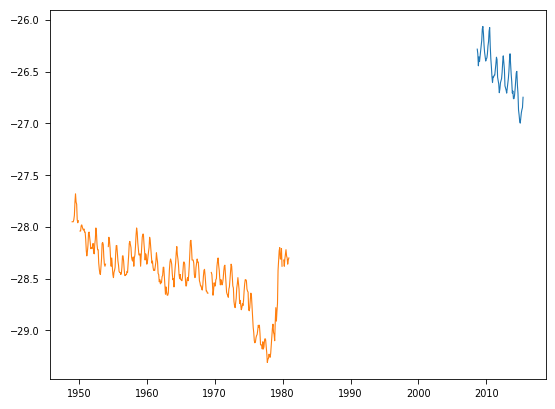

In [20]:
i = 0
file_name_1 = error_posts[i][0]
file_name_2 = error_posts[i][1]

post_1_data = pd.read_csv(os.path.join(POSTS_DIR, file_name_1))
post_2_data = pd.read_csv(os.path.join(POSTS_DIR, file_name_2))

post_1_data['datetime'] = pd.to_datetime(post_1_data['datetime'], format='%m-%Y')
post_2_data['datetime'] = pd.to_datetime(post_2_data['datetime'], format='%m-%Y')

plt.plot(post_1_data['datetime'], post_1_data['sea_level'])
plt.plot(post_2_data['datetime'], post_2_data['sea_level'])
plt.show()